In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath("..")
sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.dirname(ROOT))

from utils.recipe import Recipe, RecipeCombo
from utils.peni_env_setup import PenSimEnv
from utils.ode_patch import patch_fastodeint
from PenSimPy.pensimpy.data.constants import (
    FS, FOIL, FG, PRES, DISCHARGE, WATER, PAA,
    FS_DEFAULT_PROFILE, FOIL_DEFAULT_PROFILE, FG_DEFAULT_PROFILE,
    PRESS_DEFAULT_PROFILE, DISCHARGE_DEFAULT_PROFILE,
    WATER_DEFAULT_PROFILE, PAA_DEFAULT_PROFILE,
)
from skopt import gp_minimize
from skopt.space import Real

patch_fastodeint()

In [2]:
CONC_COL = "Penicillin Concentration"
PHYSICAL_P_MAX = 40.0
# SCALED = [DISCHARGE, FS, FOIL, FG, PRES, WATER]
# SCALED = [FS]
SCALED = [FS]
DEFAULTS = {
    FS: FS_DEFAULT_PROFILE, FOIL: FOIL_DEFAULT_PROFILE, FG: FG_DEFAULT_PROFILE,
    PRES: PRESS_DEFAULT_PROFILE, DISCHARGE: DISCHARGE_DEFAULT_PROFILE,
    WATER: WATER_DEFAULT_PROFILE, PAA: PAA_DEFAULT_PROFILE,
}

def scaled_recipe(factors):
    rd = {ch: Recipe([{"time": sp["time"], "value": sp["value"] * factors.get(ch, 1.0)}
                      for sp in prof], ch)
          for ch, prof in DEFAULTS.items()}
    return RecipeCombo(recipe_dict=rd)

def evaluate(x, seed):
    env = PenSimEnv(recipe_combo=scaled_recipe(dict(zip(SCALED, x))), fast=True)
    (df, _), batch_yield = env.get_batches(random_seed=seed, include_raman=False)
    return batch_yield, df[CONC_COL].max()

In [3]:
seed = 4
n_calls = 100
n_random = 10

baseline, _ = evaluate([1.0] * len(SCALED), seed)
log = []

def objective(x):
    y, max_c = evaluate(x, seed)
    if max_c > PHYSICAL_P_MAX:
        y = 0.0
    log.append({**dict(zip(SCALED, x)), "yield": y})
    return -y

space = [Real(0.9, 1.1, name=ch) for ch in SCALED]
gp_minimize(objective, space, n_calls=n_calls, n_initial_points=n_random,
            acq_func="EI", random_state=seed, noise=1e-10)

df = pd.DataFrame(log)

baseline 3951.5
best     3977.1  (+0.65%)
mean     3952.2  (+0.02%)
3928.7930925567
3928.3732515373617
3934.655303803788
3935.077871081061
3940.4976098682587
3935.633175748501
3938.4153796028795
3939.3325866416512
3938.1975667828237
3941.136001518581


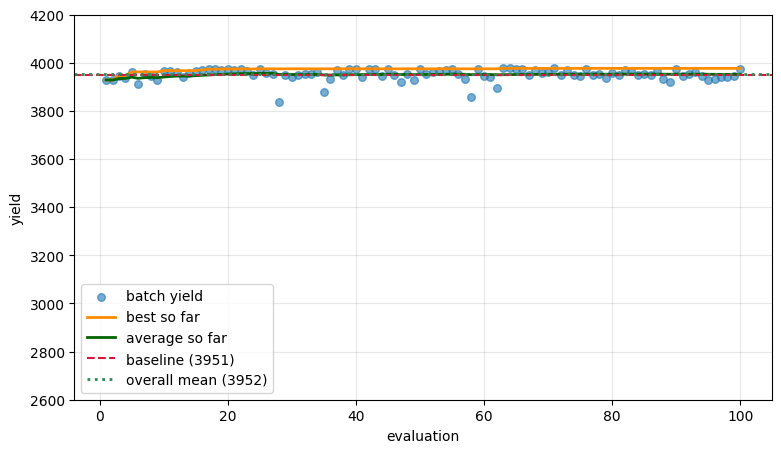

In [4]:
yields = df["yield"].values
best, mean = yields.max(), yields.mean()
print(f"baseline {baseline:.1f}")
print(f"best     {best:.1f}  ({100*(best-baseline)/baseline:+.2f}%)")
print(f"mean     {mean:.1f}  ({100*(mean-baseline)/baseline:+.2f}%)")

new = 0
for i in range(0, 10):
    new += yields[i]
    print(new/(i+1))

plt.figure(figsize=(9, 5))
plt.scatter(range(1, len(yields)+1), yields, s=30, alpha=.6, label="batch yield")
plt.plot(range(1, len(yields)+1), np.maximum.accumulate(yields), color="darkorange", lw=2, label="best so far")
plt.plot(range(1, len(yields)+1), np.cumsum(yields)/np.arange(1, len(yields)+1), color="darkgreen", lw=2, label="average so far")
plt.axhline(baseline, color="crimson", ls="--", label=f"baseline ({baseline:.0f})")
plt.axhline(mean, color="seagreen", ls=":", lw=2, label=f"overall mean ({mean:.0f})")

plt.ylim(2600, 4200) 
plt.xlabel("evaluation")
plt.ylabel("yield")
plt.legend()
plt.grid(alpha=.3)
plt.show()
# baseline 3951.5
# best     3975.3  (+0.60%)
# mean     3389.7  (-14.22%)